In [1]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEndpointEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
docs = (
    PyPDFLoader("/Users/vikrmaditya/Downloads/Code/LangGraph/Dataset/Company/Company_Policies.pdf").load()
    + PyPDFLoader("/Users/vikrmaditya/Downloads/Code/LangGraph/Dataset/Company/Company_Profile.pdf").load()
    + PyPDFLoader("/Users/vikrmaditya/Downloads/Code/LangGraph/Dataset/Company/Product_and_Pricing.pdf").load()
)

In [3]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [4]:
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embeddings = HuggingFaceEndpointEmbeddings(model=EMBED_MODEL)
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

/Users/vikrmaditya/Downloads/Code/LangGraph/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

In [6]:
class State(TypedDict):
    question: str

    # NEW: what we actually send to vector retriever
    retrieval_query: str
    rewrite_tries: int

    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]
    context: str # New

    answer: str

    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

    # NEW: usefulness check
    isuse: Literal["useful", "not_useful"]
    use_reason: str


In [7]:
# -----------------------------
# 1) Decide retrieval
# -----------------------------
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description = "True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return VALID JSON that matches this schema:\n"
            "{{\"should_retrieve\": boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=true if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=false for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose true.\n"
            "IMPORTANT: Use strictly lowercase true or false for JSON validity."
        ),
        ("human", "Question: {question}"),
    ]
)

# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    query = state['question']

    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=query)
    )

    return {"need_retrieval": decision.should_retrieve, "answer": f"Retrieval decison is {decision.should_retrieve}"}

def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state['need_retrieval']:
        return "retrieve"
    else:
        return "generate_direct"

In [8]:
# -----------------------------
# 2) Direct answer (no retrieval)
# -----------------------------
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate_direct(state: State):
    query = state['question']

    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=query
        )
    )
    return {
        "answer": out.content
    }

In [9]:
# -----------------------------
# 3) Retrieve
# -----------------------------
def retrieve(state: State) -> State:
    query = state.get("retrieval_query") or state['question']
    return {'docs': retriever.invoke(query)}

In [10]:
# -----------------------------
# 4) Relevance filter 
# -----------------------------
class RelevanceDicison(BaseModel):
    is_relevant: bool = Field(
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return VALID JSON that matches this schema:\n"
            "{{\"is_relevant\": boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question.\n"
            "IMPORTANT: Use strictly lowercase true or false for JSON validity."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relvance_llm = llm.with_structured_output(RelevanceDicison)

def is_relevant(state: State) -> State:
    
    relevant_docs = []
    retrieved_docs = state['docs']
    query = state['question']

    for doc in retrieved_docs:
        import time
        time.sleep(1.5) # Prevent Groq rate limit
        decison: RelevanceDicison = relvance_llm.invoke(
            is_relevant_prompt.format_messages(
                question = query,
                document = doc.page_content
            )
        )
        
        if decison.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

def route_after_relevance(state: State) -> Literal["generate_from_context", "no_answer_found"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "no_answer_found"

In [11]:
# -----------------------------
# 5) Generate from context
# -----------------------------
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state: State) -> State:
    # Stuff relevant docs into one block
    context = "\n\n".join(d.page_content for d in state.get("relevant_docs", [])).strip()

    if not context:
        return {'answer': "No relevant document found.", "context": ""}
    
    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question = state['question'],
            context = context
        )
    )

    return {'answer': out.content, "context": context}

def no_answer_found(state: State):
    return {"answer": "No answer found.", "context": ""}

In [12]:
# -----------------------------
# 6) IsSUP verify + revise loop
# -----------------------------
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return VALID JSON that matches this schema:\n"
            "{{\"issup\": \"fully_supported\" | \"partially_supported\" | \"no_support\", \"evidence\": [\"quote1\", \"quote2\"]}}\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

issup_llm = llm.with_structured_output(IsSUPDecision)

def is_sup(state: State) -> State:
    decision: IsSUPDecision = issup_llm.invoke(
        issup_prompt.format_messages(
            question = state['question'],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )

    return {"issup": decision.issup, "evidence": decision.evidence}

MAX_RETRIES = 10

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    # accept if fully supported
    if state.get('issup') == "fully_supported":
        return "accept_answer"

    # stop if we've already tried enough
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"   # or return a "give_up" node if you want
    
    # otherwise revise again
    return "revise_answer"

In [13]:
def accept_answer(state: State):
    return {}  # keep answer as-is

In [14]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)

def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # increment
    }

In [15]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return VALID JSON that matches this schema:\n"
            "{{\"isuse\": \"useful\" | \"not_useful\", \"reason\": \"<short reason>\"}}\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm = llm.with_structured_output(IsUSEDecision)

def is_use(state: State) -> State:
    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question = state['question'],
            answer=state.get("answer", "")
        )
    )

    return {'isuse': decision.isuse, 'use_reason': decision.reason}

MAX_REWRITE_TRIES = 3

def route_after_isuse(state: State) -> Literal["END", "no_answer_found"]:
    if state.get("isuse") == "useful":
        return "END"
    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "no_answer_found"
    
    return "rewrite_question"

In [16]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)

rewrite_llm = llm.with_structured_output(RewriteDecision)

def rewrite_question(state: State) -> State:
    decision: RewriteDecision = rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question = state['question'],
            retrieval_query = state.get("retrieval_query", ""),
            answer = state.get("answer", "")
        )
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        # optional: reset these so next pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }

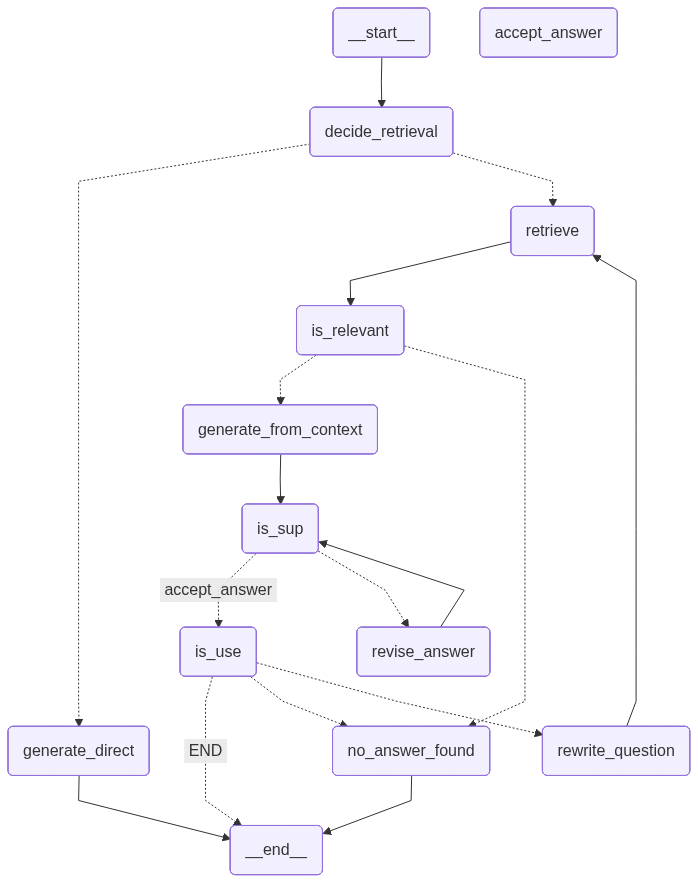

In [17]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node('decide_retrieval', decide_retrieval)
g.add_node('generate_direct', generate_direct)
g.add_node('retrieve', retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_answer_found", no_answer_found)

g.add_node("is_sup", is_sup)

# New nodes
g.add_node("accept_answer", accept_answer)
g.add_node("revise_answer", revise_answer)

# NEW: IsUSE + finalize
g.add_node("is_use", is_use)

g.add_node("rewrite_question", rewrite_question)

# --------------------
# Edges
# --------------------
g.add_edge(START, 'decide_retrieval')
g.add_conditional_edges(
    'decide_retrieval',
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve"
    }
)
g.add_edge('generate_direct', END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
         "no_answer_found": "no_answer_found",
    }
)

# If no answer found, end
g.add_edge("no_answer_found", END)

# --------------------
# Verify → (accept | revise) → verify loop
# --------------------
g.add_edge("generate_from_context", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,
    # fully_supported -> accept_answer else revise_answer
    {
        "accept_answer": "is_use",      # fully_supported (or max retries) -> go to IsUSE
        "revise_answer": "revise_answer"
    }
)

g.add_edge("revise_answer", "is_sup")  # 🔁 loop back to IsSUP

# --------------------
# IsUSE routing
#   - useful -> END
#   - not_useful -> rewrite_question -> retrieve (try again)
#   - give up -> no_answer_found -> END
# --------------------
g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "END": END,
        "rewrite_question": "rewrite_question",
        "no_answer_found": "no_answer_found",
    }
)

# rewrite -> retrieve -> relevance -> ...
g.add_edge("rewrite_question", "retrieve")

app = g.compile()
app

In [18]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "CEO of NexaAI",
    "retrieval_query": "What is the refund policy of NexaAI",  # important
    "rewrite_tries": 0,                                        # important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "not_useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")


===== RAG EXECUTION RESULT =====

Question: CEO of NexaAI
Need Retrieval: True
Rewrite tries (retrieval): 1
Support revise tries: 1

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 2

Relevant docs (source/page):
  1. source=/Users/vikrmaditya/Downloads/Code/LangGraph/Dataset/Company/Company_Profile.pdf, page=1, title=(anonymous)
  2. source=/Users/vikrmaditya/Downloads/Code/LangGraph/Dataset/Company/Company_Profile.pdf, page=0, title=(anonymous)

Verification (IsSUP):
  issup: fully_supported
  evidence:
   - Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and cloud infrastructure.
   - Aarav Mehta – CEO & Founder
   - NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.

Usefulness (IsUSE):
  isuse: useful
  reason: Directly answers the question

Final Answer:
The CEO of NexaAI is Aarav Mehta.




In [19]:
# How many employees does NexaAI have?
# Describe NexaAI’s company culture.
# Do NexaAI plans include a free trial? If yes, how many days?